# Comparison of Global Context Correlations: All Documents vs. Citable Documents

This notebook performs a systematic comparison between the correlations calculated for **All Documents** and **Citable Documents** in the Global Context across different  OpenAlex Topics.



In [1]:
#Montar mi google drive para poder usar los archivos
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:

%cd "/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments/OpenAlex/GlobalContext/"
!ls

/content/gdrive/.shortcut-targets-by-id/0B5aSrRJgnViLfm9LWl9TY21TWm5wSU0zbkgzc2YyeEp3RzJMaEJOR2FWbFkxVEZYTjNQd1E/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments/OpenAlex/GlobalContext
ai.txt
AMEASURE.txt
figuras
FMEASURE.txt
GAggregation.txt
GMEASURE.txt
ManuscriptActivityIndexFmeasure_ESI_GlobalContext.ipynb
manuscriptFiguresAndTables.html
rsi.txt
scatterplots
scatterplots.html
share.txt
Wshare.txt


In [3]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'figure.titlesize': 14,
    'figure.titleweight': 'bold'
})


In [5]:
# Define paths to the CSV files
paths = {
    'all_pearson': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments/OpenAlex/GlobalContext/pearson_correlation_AI_FMeasure.csv',
    'all_spearman': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments/OpenAlex/GlobalContext/Spearman_correlation_AI_FMeasure.csv',
    'citable_pearson': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments2026/OpenAlex/GlobalContext/pearson_correlation_AI_FMeasure.csv',
    'citable_spearman': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments2026/OpenAlex/GlobalContext/Spearman_correlation_AI_FMeasure.csv'
}

# Load files
dfs = {}
for name, path in paths.items():
    if not os.path.exists(path):
        # Try relative paths as fallback
        if '2026' in path:
            rel_path = f'Global Context/{os.path.basename(path)}'
        else:
            rel_path = f'../../ManuscriptExperiments/Global Context/{os.path.basename(path)}'
        if os.path.exists(rel_path):
            path = rel_path

    dfs[name] = pd.read_csv(path, index_col=0)
    print(f"Successfully loaded {name} (Shape: {dfs[name].shape})")


Successfully loaded all_pearson (Shape: (26, 11))
Successfully loaded all_spearman (Shape: (26, 11))
Successfully loaded citable_pearson (Shape: (26, 11))
Successfully loaded citable_spearman (Shape: (26, 11))


In [6]:
def get_comparison_table(col_name):
    """
    Creates a side-by-side comparison table for a specific correlation column.
    """
    # Base index of ESI fields from the Pearson All dataset
    index_ref = dfs['all_pearson'].index

    df_comp = pd.DataFrame(index=index_ref)

    # Pearson
    df_comp['Pearson (All)'] = dfs['all_pearson'][col_name]
    df_comp['Pearson (Citable)'] = dfs['citable_pearson'][col_name]
    df_comp['Pearson Diff (Citable - All)'] = df_comp['Pearson (Citable)'] - df_comp['Pearson (All)']

    # Spearman (aligning indices)
    df_comp['Spearman (All)'] = df_comp.index.map(dfs['all_spearman'][col_name])
    df_comp['Spearman (Citable)'] = df_comp.index.map(dfs['citable_spearman'][col_name])
    df_comp['Spearman Diff (Citable - All)'] = df_comp['Spearman (Citable)'] - df_comp['Spearman (All)']

    # Sort ESI Fields alphabetically
    df_comp = df_comp.sort_index()
    return df_comp

def display_styled_table(df, title):
    """
    Applies advanced pandas styler to color-code difference columns and display.
    """
    styled = df.style.format("{:.4f}")\
        .background_gradient(cmap="coolwarm", subset=["Pearson Diff (Citable - All)", "Spearman Diff (Citable - All)"], vmin=-0.2, vmax=0.2)\
        .set_caption(f"<b style='font-size: 14px;'>{title}</b>")\
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#f4f6f7'), ('color', '#2c3e50'), ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('text-align', 'right')]},
            {'selector': 'caption', 'props': [('margin-bottom', '10px'), ('color', '#2c3e50')]}
        ])
    display(styled)

def plot_comparison(df, user_name):
    """
    Generates side-by-side horizontal bar plots to visualize the differences in correlations.
    """
    # Prepare Pearson data for Seaborn
    df_pearson = pd.DataFrame({
        'ESI Field': df.index,
        'All Documents': df['Pearson (All)'].values,
        'Citable Documents': df['Pearson (Citable)'].values
    }).melt(id_vars='ESI Field', var_name='Dataset', value_name='Pearson Correlation')

    # Prepare Spearman data for Seaborn
    df_spearman = pd.DataFrame({
        'ESI Field': df.index,
        'All Documents': df['Spearman (All)'].values,
        'Citable Documents': df['Spearman (Citable)'].values
    }).melt(id_vars='ESI Field', var_name='Dataset', value_name='Spearman Correlation')

    fig, axes = plt.subplots(1, 2, figsize=(16, 9), sharey=True)

    # Harmonious colors: Cool Blue for All, Warm Coral for Citable
    colors = {'All Documents': '#2b7bba', 'Citable Documents': '#e76f51'}

    # Pearson Subplot
    sns.barplot(
        data=df_pearson,
        y='ESI Field',
        x='Pearson Correlation',
        hue='Dataset',
        palette=colors,
        ax=axes[0]
    )
    axes[0].set_title("Pearson Correlation Coefficient", fontsize=13, pad=10)
    axes[0].set_xlabel("Correlation Value")
    axes[0].set_ylabel("ESI Field")
    axes[0].set_xlim(-1.05, 1.05)
    axes[0].grid(True, linestyle="--", alpha=0.6, axis='x')
    axes[0].legend().set_visible(False)

    # Spearman Subplot
    sns.barplot(
        data=df_spearman,
        y='ESI Field',
        x='Spearman Correlation',
        hue='Dataset',
        palette=colors,
        ax=axes[1]
    )
    axes[1].set_title("Spearman Correlation Coefficient", fontsize=13, pad=10)
    axes[1].set_xlabel("Correlation Value")
    axes[1].set_ylabel("")
    axes[1].set_xlim(-1.05, 1.05)
    axes[1].grid(True, linestyle="--", alpha=0.6, axis='x')
    axes[1].legend().set_visible(False)

    # Add single common legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=2, fontsize=11)

    plt.suptitle(f"Correlation Comparison: {user_name} (All vs. Citable)", fontsize=15, y=1.03)
    plt.tight_layout()
    plt.show()


## 1. AI vs DShareC Correlation Comparison

This section compares the Pearson and Spearman correlations of **Activity Index (AI)** versus **DShareC**.
This indicator measures how the proportion of publications (AI) relates to the document share in the citation distribution.


,Pearson (All),Pearson (Citable),Pearson Diff (Citable - All),Spearman (All),Spearman (Citable),Spearman Diff (Citable - All)
Agricultural and Biological Sciences,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
Arts and Humanities,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
"Biochemistry, Genetics and Molecular Biology",1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
"Business, Management and Accounting",1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
Chemical Engineering,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
Chemistry,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
Computer Science,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
Decision Sciences,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
Dentistry,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
Earth and Planetary Sciences,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000


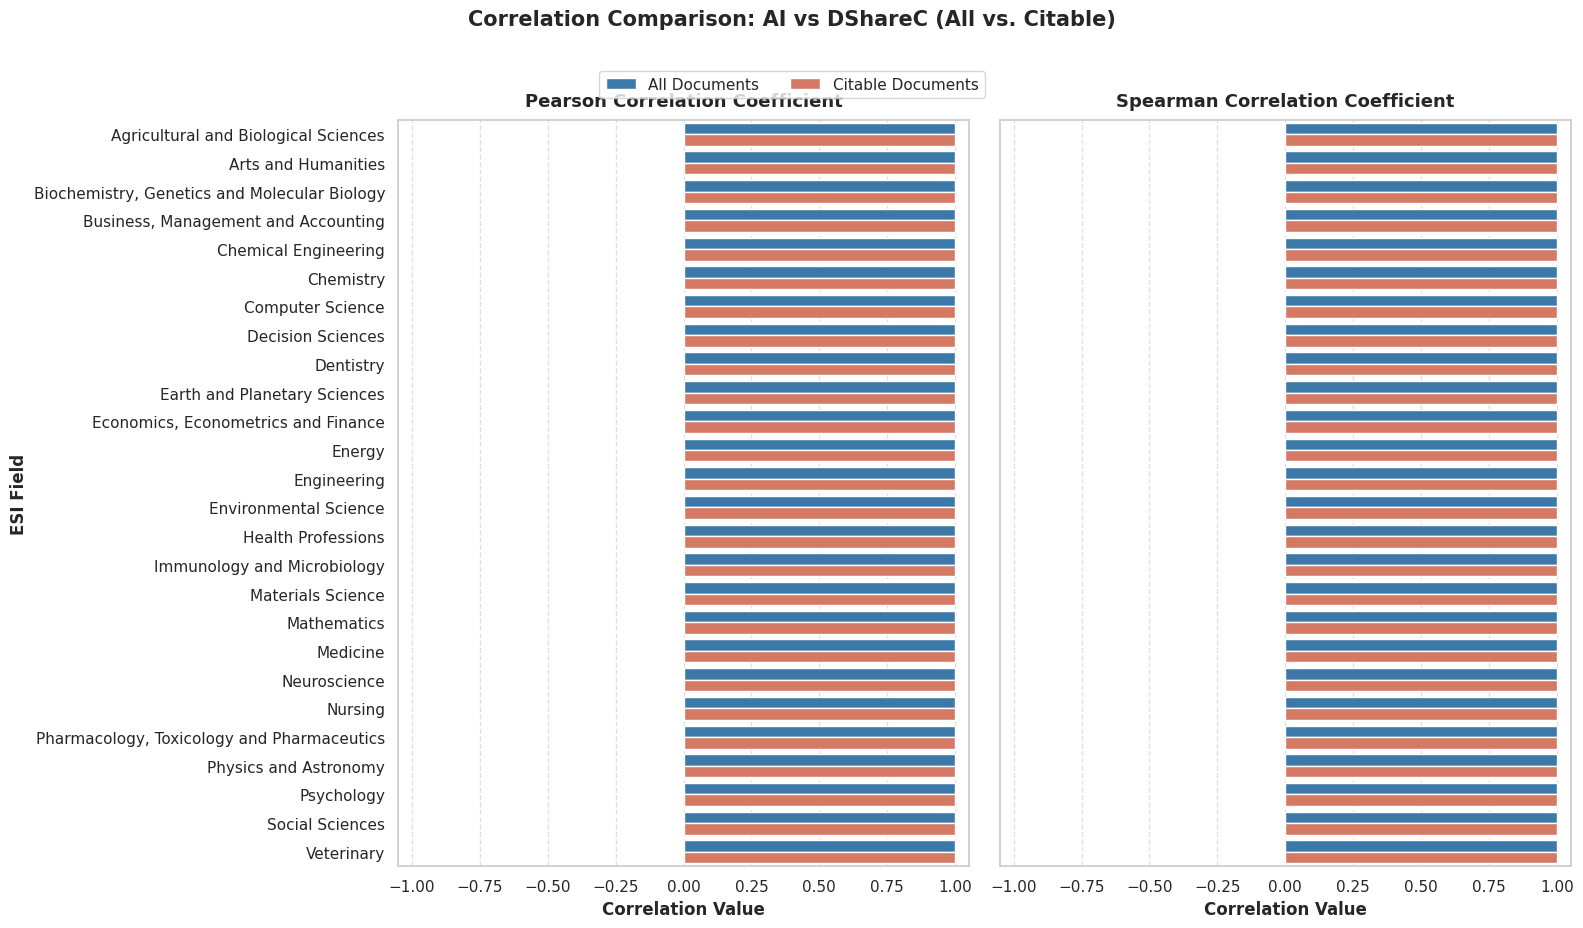

In [7]:
df_ai_dsharec = get_comparison_table('AI vs DShareC')
display_styled_table(df_ai_dsharec, 'Table 1: AI vs DShareC (All vs. Citable)')
plot_comparison(df_ai_dsharec, 'AI vs DShareC')


## 2. AI vs CShareD Correlation Comparison

This section compares the correlations of **Activity Index (AI)** versus **CShareD**.


,Pearson (All),Pearson (Citable),Pearson Diff (Citable - All),Spearman (All),Spearman (Citable),Spearman Diff (Citable - All)
Engineering,0.2360,0.2921,0.0561,0.7155,0.7270,0.0115
Physics and Astronomy,0.1459,0.1234,-0.0225,0.6494,0.6636,0.0142
Materials Science,0.1957,0.2550,0.0593,0.5941,0.6240,0.0298
Neuroscience,0.2805,0.2455,-0.0350,0.5023,0.4606,-0.0417
Computer Science,0.1462,0.1630,0.0167,0.4850,0.5081,0.0231
Chemistry,0.0853,0.2473,0.1620,0.4838,0.4471,-0.0367
"Biochemistry, Genetics and Molecular Biology",0.2278,0.1650,-0.0628,0.4184,0.3447,-0.0737
Chemical Engineering,0.1534,0.2119,0.0585,0.3892,0.4503,0.0611
Energy,0.1015,0.1324,0.0310,0.2997,0.3550,0.0554
Mathematics,-0.0049,0.0196,0.0245,0.2728,0.3967,0.1239


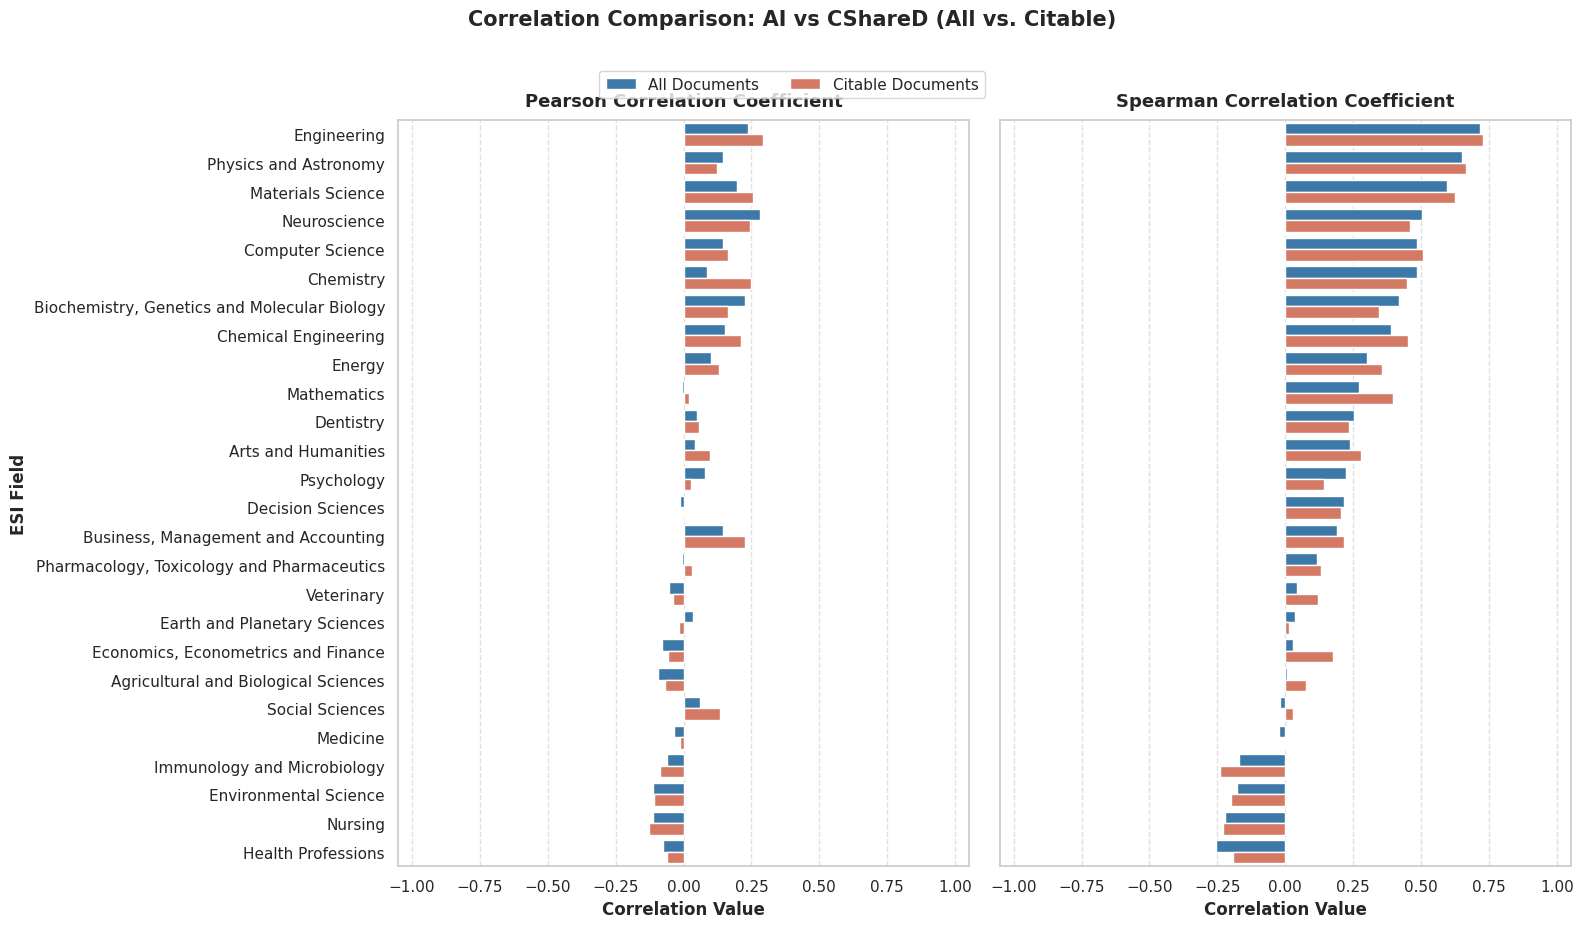

In [8]:
df_ai_cshared = get_comparison_table('AI vs CShareD')
display_styled_table(df_ai_cshared.sort_values('Spearman (All)', ascending=False), 'Table 2: AI vs CShareD (All vs. Citable)')
plot_comparison(df_ai_cshared.sort_values('Spearman (All)', ascending=False), 'AI vs CShareD')


## 3. F-Measure vs DShareC (ShareC) Correlation Comparison

This section compares the correlations of **F-Measure** versus **DShareC**.


,Pearson (All),Pearson (Citable),Pearson Diff (Citable - All),Spearman (All),Spearman (Citable),Spearman Diff (Citable - All)
Engineering,0.2737,0.3474,0.0736,0.7193,0.7306,0.0113
Physics and Astronomy,0.2556,0.2584,0.0028,0.6693,0.6889,0.0195
Materials Science,0.3153,0.4316,0.1163,0.6154,0.6422,0.0267
Neuroscience,0.4715,0.4297,-0.0418,0.5377,0.5027,-0.0349
Chemistry,0.1508,0.4675,0.3167,0.5125,0.4807,-0.0318
Computer Science,0.1936,0.2142,0.0206,0.4930,0.5151,0.0221
Chemical Engineering,0.2660,0.3811,0.1151,0.4840,0.5660,0.0820
"Biochemistry, Genetics and Molecular Biology",0.3024,0.2253,-0.0771,0.4309,0.3564,-0.0745
Energy,0.1927,0.2746,0.0819,0.3565,0.4164,0.0599
Dentistry,0.2256,0.2653,0.0398,0.3556,0.3459,-0.0097


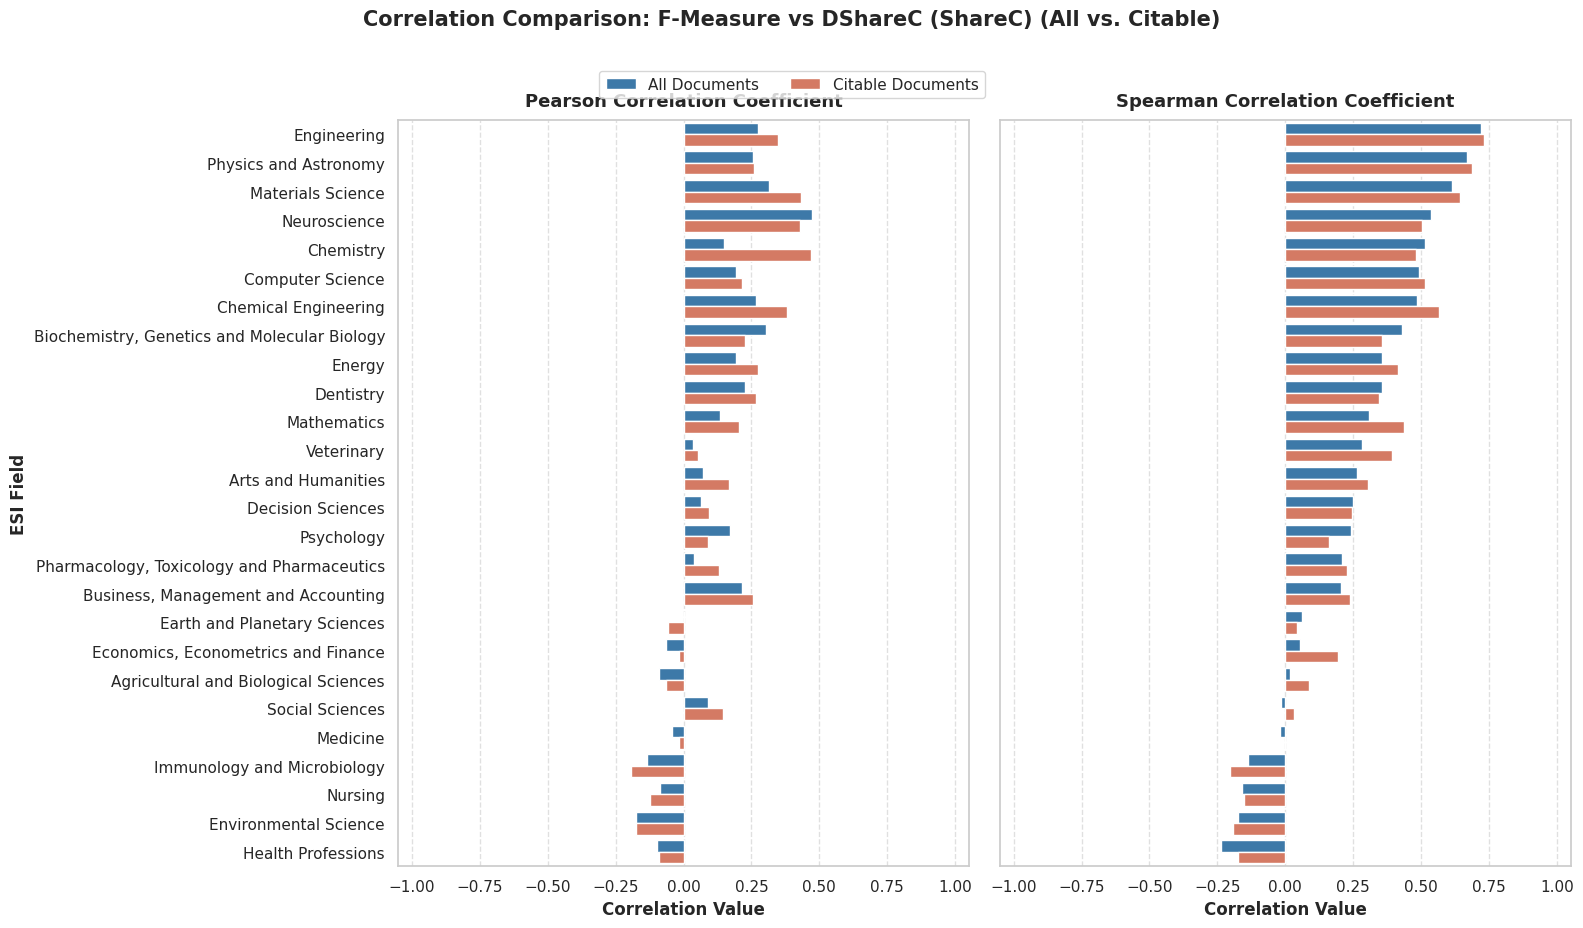

In [9]:
df_f_dsharec = get_comparison_table('F-Measure vs DShareC')
display_styled_table(df_f_dsharec.sort_values('Spearman (All)', ascending=False), 'Table 3: F-Measure vs DShareC (All vs. Citable)')
plot_comparison(df_f_dsharec.sort_values('Spearman (All)', ascending=False), 'F-Measure vs DShareC (ShareC)')


## 4. F-Measure vs CShareD Correlation Comparison

This section compares the correlations of **F-Measure** versus **CShareD**.


,Pearson (All),Pearson (Citable),Pearson Diff (Citable - All),Spearman (All),Spearman (Citable),Spearman Diff (Citable - All)
Medicine,0.9864,0.9815,-0.0049,1.0000,1.0000,-0.0000
Environmental Science,0.9123,0.8850,-0.0273,0.9999,0.9999,-0.0000
Social Sciences,0.9780,0.9869,0.0089,0.9999,0.9999,-0.0000
Engineering,0.9864,0.9838,-0.0026,0.9999,0.9999,-0.0000
Computer Science,0.9567,0.9418,-0.0149,0.9999,0.9998,-0.0001
Agricultural and Biological Sciences,0.9034,0.9050,0.0016,0.9998,0.9996,-0.0002
"Biochemistry, Genetics and Molecular Biology",0.9306,0.8962,-0.0343,0.9997,0.9997,0.0000
Psychology,0.8596,0.8335,-0.0260,0.9996,0.9995,-0.0002
Health Professions,0.8588,0.8642,0.0054,0.9996,0.9992,-0.0004
"Business, Management and Accounting",0.9271,0.9587,0.0316,0.9995,0.9993,-0.0002


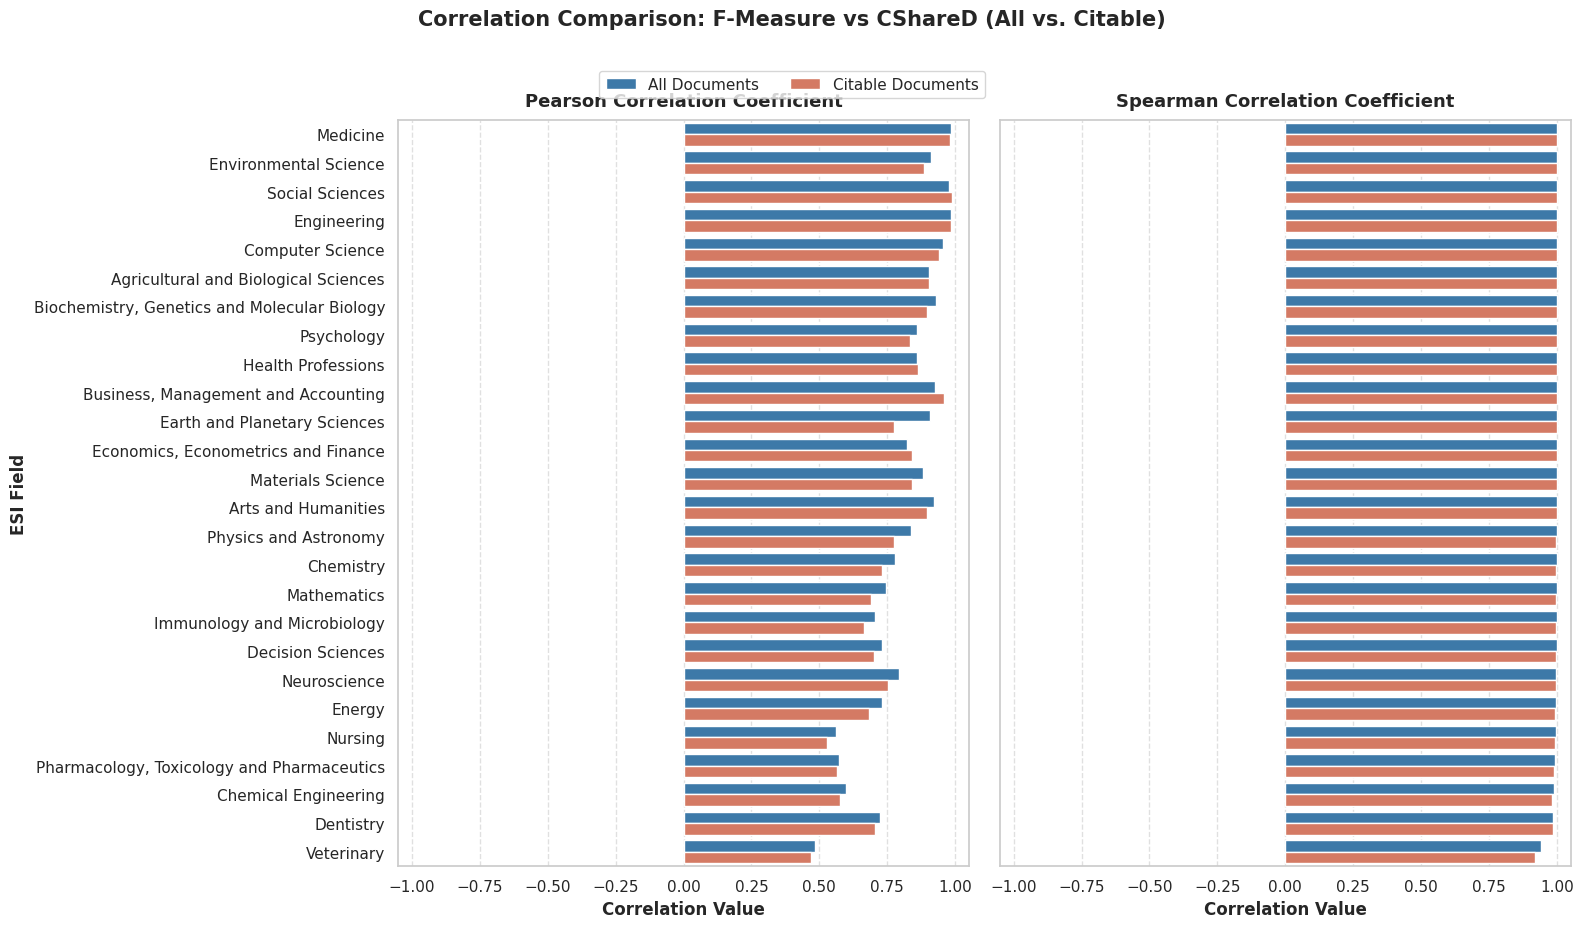

In [10]:
df_f_cshared = get_comparison_table('F-Measure vs CShareD')
display_styled_table(df_f_cshared.sort_values('Spearman (All)', ascending=False), 'Table 4: F-Measure vs CShareD (All vs. Citable)')
plot_comparison(df_f_cshared.sort_values('Spearman (All)', ascending=False), 'F-Measure vs CShareD')


## 5. Summary Statistics and Overall Analysis (Absolute Discrepancies)

To synthesize the comparison, let's look at the summary statistics of the **absolute differences** across all 22 ESI fields for each of the four indicator pairs.

Using absolute values is essential because it measures the magnitude of the discrepancy (change) regardless of whether the correlation went up or down. For example, a large negative change like -0.76708 represents a major discrepancy of 0.76708 in absolute terms. Computing statistics on signed differences can cause positive and negative changes to cancel each other out, hiding the true extent of the changes.


In [11]:
summary_data = []
pairs_mapping = {
    'AI vs DShareC': 'AI vs DShareC',
    'AI vs CShareD': 'AI vs CShareD',
    'F-Measure vs DShareC': 'F-Measure vs DShareC',
    'F-Measure vs CShareD': 'F-Measure vs CShareD'
}

for user_name, csv_name in pairs_mapping.items():
    df_p = get_comparison_table(csv_name)
    pearson_abs = df_p['Pearson Diff (Citable - All)'].abs()
    spearman_abs = df_p['Spearman Diff (Citable - All)'].abs()
    summary_data.append({
        'Indicator Pair': user_name,
        'Mean Abs Pearson Diff': pearson_abs.mean(),
        'Median Abs Pearson Diff': pearson_abs.median(),
        'Max Abs Pearson Diff': pearson_abs.max(),
        'Min Abs Pearson Diff': pearson_abs.min(),
        'Mean Abs Spearman Diff': spearman_abs.mean(),
        'Median Abs Spearman Diff': spearman_abs.median(),
        'Max Abs Spearman Diff': spearman_abs.max(),
        'Min Abs Spearman Diff': spearman_abs.min()
    })

df_summary = pd.DataFrame(summary_data).set_index('Indicator Pair')

styled_summary = df_summary.style.format("{:.5f}")\
    .background_gradient(cmap="Reds", vmin=0.0, vmax=0.3)\
    .set_caption("<b style='font-size: 14px;'>Overall Comparison Summary: Absolute Discrepancies (|Citable - All|)</b>")\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'right')]},
        {'selector': 'caption', 'props': [('margin-bottom', '10px'), ('color', '#2c3e50')]}
    ])
display(styled_summary)


,Mean Abs Pearson Diff,Median Abs Pearson Diff,Max Abs Pearson Diff,Min Abs Pearson Diff,Mean Abs Spearman Diff,Median Abs Spearman Diff,Max Abs Spearman Diff,Min Abs Spearman Diff
Indicator Pair,,,,,,,,
AI vs DShareC,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
AI vs CShareD,0.04049,0.02938,0.16201,0.00636,0.04613,0.03742,0.14427,0.00780
F-Measure vs DShareC,0.06311,0.05347,0.31668,0.00202,0.04754,0.03477,0.13842,0.00325
F-Measure vs CShareD,0.03001,0.02633,0.13083,0.00157,0.00172,0.00050,0.02137,0.00000
